In [7]:
import numpy as np
import cmath
import math
import sympy as sp
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as spstat
import statsmodels.distributions.empirical_distribution as empir
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot

### Oefening 79
Een onderzoeker is geïnteresseerd in de breeksterkte van verschillende gelamineerde balken gemaakt uit drie houtvariëteiten en drie verschillende soorten lijm. Om deze te vergelijken werden vijf balken van elk van de negen combinaties aangemaakt en daarna onderworpen aan een spanningstest. De data bestaat uit waarden voor de druk waarbij de balken braken. Maak een vergelijkend onderzoek en controleer eventuele assumpties.

Data : balken.csv

In [2]:
data = pd.read_csv('bestanden/balken.csv')
L1=data.druk[0:15]
L2=data.druk[15:30]
L3=data.druk[30:45]
H1=data.loc[data['hout']==1,'druk']
H2=data.loc[data['hout']==2,'druk']
H3=data.loc[data['hout']==3,'druk']

In [3]:
gemL1=np.mean(L1)
sL1=np.std(L1,ddof=1)
D,p=spstat.kstest(L1,spstat.norm(gemL1,sL1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemL2=np.mean(L2)
sL2=np.std(L2,ddof=1)
D,p=spstat.kstest(L2,spstat.norm(gemL2,sL2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemL3=np.mean(L3)
sL3=np.std(L3,ddof=1)
D,p=spstat.kstest(L3,spstat.norm(gemL3,sL3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1316 als teststatistiek, met bijhorende p-waarde 0.9273.
De KS-test heeft 0.2184 als teststatistiek, met bijhorende p-waarde 0.4125.
De KS-test heeft 0.3021 als teststatistiek, met bijhorende p-waarde 0.1036.


In [4]:
gemH1=np.mean(H1)
sH1=np.std(H1,ddof=1)
D,p=spstat.kstest(H1,spstat.norm(gemH1,sH1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemH2=np.mean(H2)
sH2=np.std(H2,ddof=1)
D,p=spstat.kstest(H2,spstat.norm(gemH2,sH2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemH3=np.mean(H3)
sH3=np.std(H3,ddof=1)
D,p=spstat.kstest(H3,spstat.norm(gemH3,sH3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1658 als teststatistiek, met bijhorende p-waarde 0.7448.
De KS-test heeft 0.1457 als teststatistiek, met bijhorende p-waarde 0.8639.
De KS-test heeft 0.1309 als teststatistiek, met bijhorende p-waarde 0.9300.


In [5]:
levene_stat, levene_p = spstat.levene(L1,L2,L3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")
levene_stat, levene_p = spstat.levene(H1,H2,H3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

Levene's test: statistiek = 0.2213, p-waarde = 0.8024
Levene's test: statistiek = 0.4923, p-waarde = 0.6147


In [9]:
model = ols('druk ~C(lijm) + C(hout) + C(lijm):C(hout)',data=data).fit()
print(anova_lm(model,typ=2))

                      sum_sq    df          F    PR(>F)
C(lijm)          6643.733333   2.0  20.118977  0.000001
C(hout)           682.533333   2.0   2.066891  0.141339
C(lijm):C(hout)  2715.733333   4.0   4.111978  0.007600
Residual         5944.000000  36.0        NaN       NaN


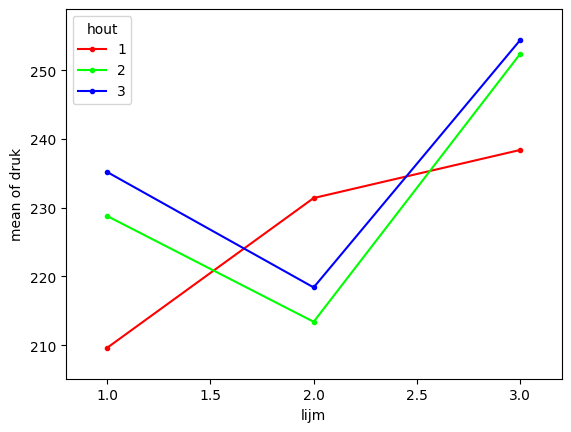

In [10]:
fig=interaction_plot(data.lijm,data.hout,data.druk)

### Oefening 80
Men wenst onderzoek te doen rond verschillende samenstellingen om het wegdek van de snelweg mee te bouwen. Bij een proefproject worden de vier verschillende types wegdek (die verschillen qua samenstelling van de asfalt) gebruikt op de E17, de E40, de R4 en de E413, telkens met een strook van 1 km. Na vijf jaar wordt geëvalueerd hoeveel herstellingen dienden te gebeuren (zie tabel). Maak een totale variantie-analyse voor wat betreft de types wegdek op de verschillende snelwegen.

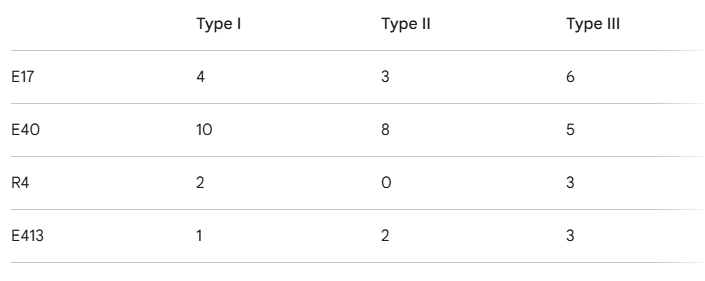

In [13]:
data=pd.DataFrame({'snelweg': np.repeat(['E17','E40','R4','E412'],4),
                   'type': np.tile(['I','II','III','IV'],4),
                   'aantal': [4,3,6,10,
                              10,8,5,16,
                              2,0,3,4,
                              1,2,3,4]})

In [14]:
model=ols('aantal ~ C(snelweg) + C(type)',data=data).fit()
print(anova_lm(model,typ=2))

              sum_sq   df          F    PR(>F)
C(snelweg)  147.6875  3.0  10.660150  0.002554
C(type)      65.6875  3.0   4.741353  0.029988
Residual     41.5625  9.0        NaN       NaN


### Oefening 81
Op verschillende plaatsen worden watermonsters genomen en het zuurstofgehalte bepaald:
plaats 1: stroomopwaarts
plaats 2: nabij een fabriek
plaats 3: stroomafwaarts
Ga na of er een significant verschil is tussen de plaatsen.

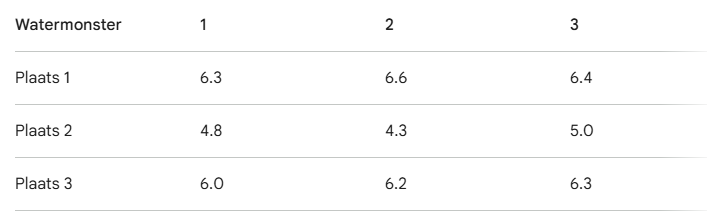

In [15]:
P1=[6.3,6.6,6.4,6.4,6.5]
P2=[4.8,4.3,5.0,4.7,5.1]
P3=[6.0,6.2,6.3,5.8,6.2]

In [17]:
gemP1=np.mean(P1)
sP1=np.std(P1,ddof=1)
D,p=spstat.kstest(P1,spstat.norm(gemP1,sP1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP2=np.mean(P2)
sP2=np.std(P2,ddof=1)
D,p=spstat.kstest(P2,spstat.norm(gemP2,sP2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP3=np.mean(P3)
sP3=np.std(P3,ddof=1)
D,p=spstat.kstest(P3,spstat.norm(gemP3,sP3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.2371 als teststatistiek, met bijhorende p-waarde 0.8821.
De KS-test heeft 0.1986 als teststatistiek, met bijhorende p-waarde 0.9641.
De KS-test heeft 0.2915 als teststatistiek, met bijhorende p-waarde 0.6974.


In [18]:
levene_stat, levene_p = spstat.levene(P1,P2,P3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

Levene's test: statistiek = 1.5228, p-waarde = 0.2574


In [19]:
Fwaarde,pwaardeA=spstat.f_oneway(P1,P2,P3)
print("F-statistiek = ", Fwaarde, ", p-waarde = ",pwaardeA)

F-statistiek =  76.89333333333362 , p-waarde =  1.438102623123067e-07


In [20]:
print(spstat.tukey_hsd(P1,P2,P3))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      1.660     0.000     1.283     2.037
 (0 - 2)      0.340     0.079    -0.037     0.717
 (1 - 0)     -1.660     0.000    -2.037    -1.283
 (1 - 2)     -1.320     0.000    -1.697    -0.943
 (2 - 0)     -0.340     0.079    -0.717     0.037
 (2 - 1)      1.320     0.000     0.943     1.697



C:\Users\Talia\AppData\Local\Temp\ipykernel_13128\3512491246.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([P1,P2,P3],labels=['plaats 1', 'plaats 2', 'plaats 3'])


{'whiskers': [<matplotlib.lines.Line2D at 0x284e09e8590>,
 'caps': [<matplotlib.lines.Line2D at 0x284e09e8830>,
 'boxes': [<matplotlib.lines.Line2D at 0x284e09e8440>,
 'medians': [<matplotlib.lines.Line2D at 0x284e09e8ad0>,
 'fliers': [<matplotlib.lines.Line2D at 0x284e09e8c20>,
 'means': []}

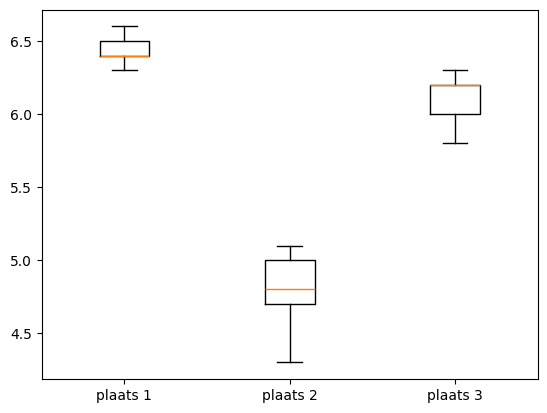

In [22]:
plt.boxplot([P1,P2,P3],labels=['plaats 1', 'plaats 2', 'plaats 3'])

### Oefening 82  
Er wordt een studie gedaan waarin de Fe-concentratie bepaald wordt in grondstalen. Op 3 verschillende plaatsen worden telkens zes stalen genomen en de metingen op elk staal worden uitgevoerd in 2 verschillende labo's, die elk een andere meettechniek gebruiken.In de onderstaande tabel worden de resultaten weergegeven.Ga na in hoeverre het labo (factor A) en de plaats (factor B) effect hebben op de meting ($\alpha=0.05$).  

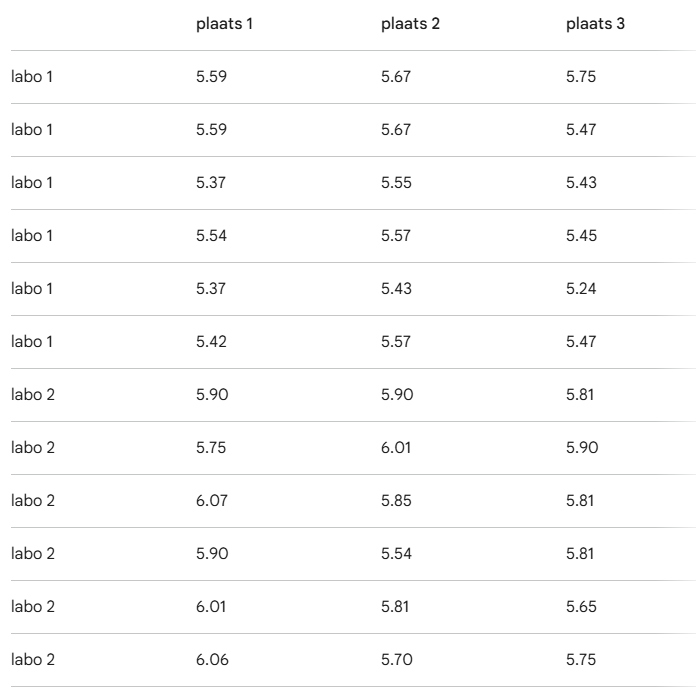

In [23]:
data=pd.DataFrame({'labo': np.repeat(['labo 1', 'Labo 2'],18),
                   'plaats': np.tile(np.repeat(['plaats 1', 'plaats 2', 'plaats 3'],6),2),
                   'ijzerconcentratie': [5.59,5.59,5.37,5.54,5.37,5.42,
                                         5.67,5.67,5.55,5.57,5.43,5.57,
                                         5.75,5.47,5.43,5.45,5.24,5.47,
                                         5.90,5.75,6.07,5.90,6.01,6.06,
                                         5.90,6.01,5.85,5.54,5.81,5.70,
                                         5.81,5.90,5.81,5.81,5.65,5.75]})

In [24]:
L1=data.ijzerconcentratie[0:18]
L2=data.ijzerconcentratie[18:36]
P1=data.loc[data['plaats']=='plaats 1', 'ijzerconcentratie']
P2=data.loc[data['plaats']=='plaats 2', 'ijzerconcentratie']
P3=data.loc[data['plaats']=='plaats 3', 'ijzerconcentratie']

In [25]:
gemL1=np.mean(L1)
sL1=np.std(L1,ddof=1)
D,p=spstat.kstest(L1,spstat.norm(gemL1,sL1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemL2=np.mean(L2)
sL2=np.std(L2,ddof=1)
D,p=spstat.kstest(L2,spstat.norm(gemL2,sL2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP1=np.mean(P1)
sP1=np.std(P1,ddof=1)
D,p=spstat.kstest(P1,spstat.norm(gemP1,sP1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP2=np.mean(P2)
sP2=np.std(P2,ddof=1)
D,p=spstat.kstest(P2,spstat.norm(gemP2,sP2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP3=np.mean(P3)
sP3=np.std(P3,ddof=1)
D,p=spstat.kstest(P3,spstat.norm(gemP3,sP3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1193 als teststatistiek, met bijhorende p-waarde 0.9335.
De KS-test heeft 0.1290 als teststatistiek, met bijhorende p-waarde 0.8887.
De KS-test heeft 0.1786 als teststatistiek, met bijhorende p-waarde 0.7776.
De KS-test heeft 0.1723 als teststatistiek, met bijhorende p-waarde 0.8113.
De KS-test heeft 0.2209 als teststatistiek, met bijhorende p-waarde 0.5305.


In [26]:
levene_stat, levene_p = spstat.levene(L1,L2,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")
levene_stat, levene_p = spstat.levene(P1,P2,P3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

Levene's test: statistiek = 0.0668, p-waarde = 0.7977
Levene's test: statistiek = 2.9567, p-waarde = 0.0659


In [28]:
model = ols('ijzerconcentratie ~ C(labo) + C(plaats) + C(labo):C(plaats)',data=data).fit()
print(anova_lm(model,typ=2))

                     sum_sq    df          F        PR(>F)
C(labo)            1.026844   1.0  65.201072  5.165327e-09
C(plaats)          0.046772   2.0   1.484937  2.426942e-01
C(labo):C(plaats)  0.090239   2.0   2.864929  7.266906e-02
Residual           0.472467  30.0        NaN           NaN


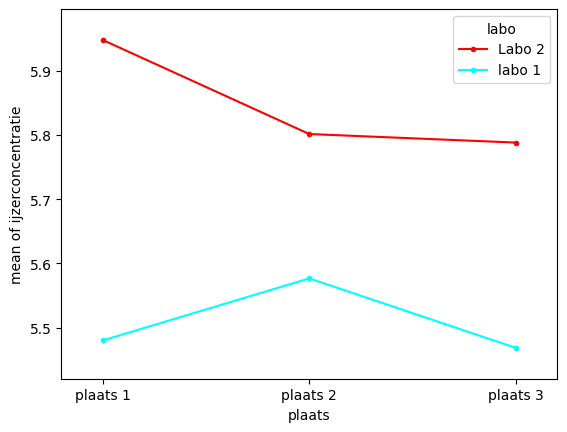

In [29]:
fig=interaction_plot(data.plaats,data.labo,data.ijzerconcentratie)

C:\Users\Talia\AppData\Local\Temp\ipykernel_13128\2523468741.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([L1,L2],labels=['labo 1', 'labo 2'])


{'whiskers': [<matplotlib.lines.Line2D at 0x284e0c9b380>,
 'caps': [<matplotlib.lines.Line2D at 0x284e0c9b620>,
 'boxes': [<matplotlib.lines.Line2D at 0x284e0c9b230>,
 'medians': [<matplotlib.lines.Line2D at 0x284e0c9b8c0>,
 'fliers': [<matplotlib.lines.Line2D at 0x284e0c9ba10>,
 'means': []}

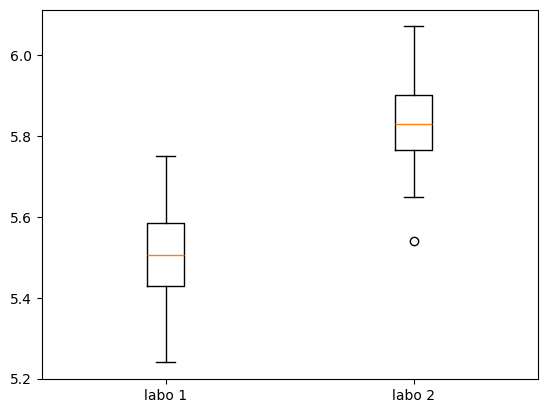

In [32]:
plt.boxplot([L1,L2],labels=['labo 1', 'labo 2'])

C:\Users\Talia\AppData\Local\Temp\ipykernel_13128\1761596198.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([P1,P2,P3],labels=['plaats 1','plaats 2','plaats 3'])


{'whiskers': [<matplotlib.lines.Line2D at 0x284e0d17230>,
 'caps': [<matplotlib.lines.Line2D at 0x284e0d174d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x284e0d170e0>,
 'medians': [<matplotlib.lines.Line2D at 0x284e0d17770>,
 'fliers': [<matplotlib.lines.Line2D at 0x284e0d178c0>,
 'means': []}

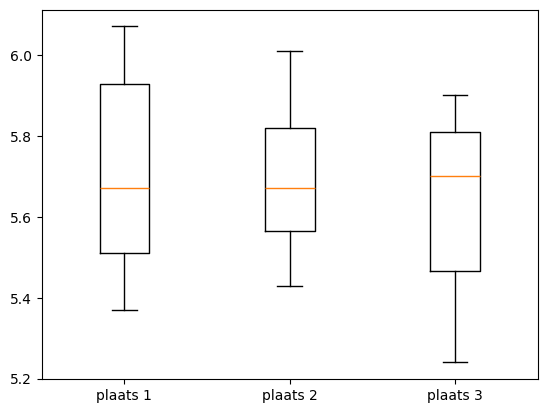

In [33]:
plt.boxplot([P1,P2,P3],labels=['plaats 1','plaats 2','plaats 3'])